# Gaussian Naive Bayes: Deep Dive
## Loan Default Prediction (HMEQ Dataset)

*Part of the [ML Model Comparison](../loan_default_tradeoff_matrix.html) series on bitterscientist.com*

This notebook covers:
1. The math behind Naive Bayes (Bayes' theorem, Gaussian likelihood, naive independence)
2. Worked examples using actual HMEQ data
3. Model training and evaluation
4. Diagnostic visualizations (exported as interactive plotly HTML)
5. Results interpretation

---
## 1. Setup

In [1]:
import sys
sys.path.insert(0, ".")
from shared_utils import *

from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA

MODEL_NAME = "Gaussian Naive Bayes"
MODEL_SLUG = "naive_bayes"

(X_train, X_test, y_train, y_test, df, df_proc,
 prep_linear, prep_tree, cv,
 numeric_features, categorical_features, pos_weight) = load_and_prep()

Dataset loaded: 5960 rows, 13 columns
Default rate: 19.95%
Train: 4470 | Test: 1490
Numeric features: 15 | Categorical: 2
Positive class weight: 4.01


---
## 2. The Math Behind Naive Bayes

### 2.1 Bayes' Theorem

The foundation is Bayes' theorem, which relates the posterior probability to the likelihood and prior:

$$P(Y=c \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid Y=c) \cdot P(Y=c)}{P(\mathbf{x})}$$

where:
- $P(Y=c \mid \mathbf{x})$ is the **posterior**: probability of class $c$ given features
- $P(\mathbf{x} \mid Y=c)$ is the **likelihood**: probability of observing these features given class $c$
- $P(Y=c)$ is the **prior**: base probability of class $c$ (e.g., 20% default rate)
- $P(\mathbf{x})$ is the **evidence**: normalizing constant (same for all classes)

For classification, we only need to compare posteriors across classes, so we can ignore $P(\mathbf{x})$:

$$\hat{y} = \arg\max_c \ P(\mathbf{x} \mid Y=c) \cdot P(Y=c)$$

### 2.2 The Naive Independence Assumption

The "naive" in Naive Bayes is the assumption that features are **conditionally independent** given the class:

$$P(\mathbf{x} \mid Y=c) = \prod_{j=1}^{p} P(x_j \mid Y=c)$$

This is almost never true in practice (e.g., LOAN and VALUE are correlated), but it dramatically simplifies computation and often works surprisingly well.

### 2.3 Gaussian Likelihood

For continuous features, Gaussian NB assumes each feature follows a normal distribution within each class:

$$P(x_j \mid Y=c) = \frac{1}{\sqrt{2\pi\sigma_{jc}^2}} \exp\left(-\frac{(x_j - \mu_{jc})^2}{2\sigma_{jc}^2}\right)$$

where $\mu_{jc}$ and $\sigma_{jc}^2$ are the mean and variance of feature $j$ in class $c$, estimated from the training data.

### 2.4 Full Classification Rule

Combining Bayes' theorem with the naive assumption and Gaussian likelihood:

$$P(Y=c \mid \mathbf{x}) \propto P(Y=c) \prod_{j=1}^{p} \frac{1}{\sqrt{2\pi\sigma_{jc}^2}} \exp\left(-\frac{(x_j - \mu_{jc})^2}{2\sigma_{jc}^2}\right)$$

Taking the log (for numerical stability):

$$\ln P(Y=c \mid \mathbf{x}) \propto \ln P(Y=c) + \sum_{j=1}^{p} \left[-\frac{1}{2}\ln(2\pi\sigma_{jc}^2) - \frac{(x_j - \mu_{jc})^2}{2\sigma_{jc}^2}\right]$$

### 2.5 Training

Training is just computing sufficient statistics:
- **Prior**: $P(Y=c) = \frac{n_c}{n}$
- **Mean**: $\mu_{jc} = \frac{1}{n_c}\sum_{i: y_i=c} x_{ij}$
- **Variance**: $\sigma_{jc}^2 = \frac{1}{n_c}\sum_{i: y_i=c} (x_{ij} - \mu_{jc})^2$

This makes training extremely fast: $O(n \cdot p)$ time and $O(p \cdot C)$ space.

### 2.6 Var Smoothing

Sklearn adds a small value $\epsilon = \text{var\_smoothing} \times \max(\sigma^2)$ to all variances to prevent division by zero and improve numerical stability.

---
## 3. Feature Likelihood Distributions

Let's visualize how the Gaussian assumption looks for key HMEQ features.

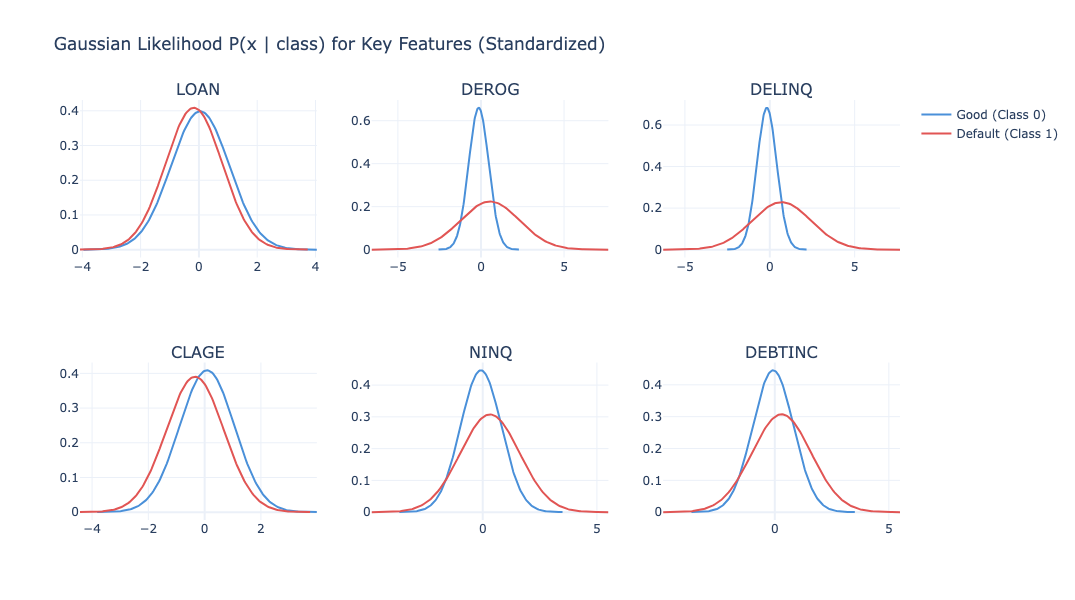

  Saved: outputs/naive_bayes/feature_likelihoods.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/naive_bayes/feature_likelihoods.html')

In [2]:
# Transform data
X_train_t = prep_linear.fit_transform(X_train)
X_test_t = prep_linear.transform(X_test)

cat_encoder = prep_linear.named_transformers_["cat"]
cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_names

# Train NB for parameter extraction
gnb = GaussianNB()
gnb.fit(X_train_t, y_train)

# Plot likelihood distributions for top numeric features
top_features = ["DELINQ", "DEROG", "DEBTINC", "CLAGE", "NINQ", "LOAN"]
top_indices = [i for i, name in enumerate(all_feature_names) if name in top_features]

from plotly.subplots import make_subplots
n_plots = len(top_indices)
fig = make_subplots(rows=2, cols=3, subplot_titles=[all_feature_names[i] for i in top_indices])

for plot_idx, feat_idx in enumerate(top_indices):
    row = plot_idx // 3 + 1
    col = plot_idx % 3 + 1

    for c, color, name in [(0, COLORS["accent"], "Good"), (1, COLORS["red"], "Default")]:
        mu = gnb.theta_[c, feat_idx]
        sigma = np.sqrt(gnb.var_[c, feat_idx])
        x_range = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
        pdf = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_range - mu) / sigma)**2)

        fig.add_trace(go.Scatter(
            x=x_range, y=pdf, mode="lines", name=f"{name} (Class {c})",
            line=dict(color=color, width=2),
            showlegend=(plot_idx == 0),
        ), row=row, col=col)

fig.update_layout(
    title="Gaussian Likelihood P(x | class) for Key Features (Standardized)",
    height=600, width=900,
)
fig.show()
save_chart(fig, MODEL_SLUG, "feature_likelihoods")

---
## 4. Worked Example with HMEQ Data

In [3]:
examples = get_example_rows(df, n=3)

print("=" * 70)
print("WORKED EXAMPLE: Manual Naive Bayes Prediction")
print("=" * 70)

# Use first test sample
test_idx = 0
x_query = X_test_t[test_idx]
actual = y_test.iloc[test_idx]

print(f"\nQuery borrower (Actual: {'DEFAULT' if actual == 1 else 'GOOD'})")

# Prior probabilities
prior_0 = gnb.class_prior_[0]
prior_1 = gnb.class_prior_[1]
print(f"\nStep 1: Prior probabilities (from training data)")
print(f"  P(Good)    = {prior_0:.4f}")
print(f"  P(Default) = {prior_1:.4f}")

# Log-likelihoods for a few features
print(f"\nStep 2: Compute log-likelihoods for each feature")
log_like_0 = np.log(prior_0)
log_like_1 = np.log(prior_1)

# Show first 5 features
for j in range(min(5, len(all_feature_names))):
    mu_0, mu_1 = gnb.theta_[0, j], gnb.theta_[1, j]
    var_0, var_1 = gnb.var_[0, j], gnb.var_[1, j]
    x_j = x_query[j]

    ll_0 = -0.5 * np.log(2 * np.pi * var_0) - (x_j - mu_0)**2 / (2 * var_0)
    ll_1 = -0.5 * np.log(2 * np.pi * var_1) - (x_j - mu_1)**2 / (2 * var_1)

    log_like_0 += ll_0
    log_like_1 += ll_1

    print(f"  {all_feature_names[j]:15s}: x={x_j:+.3f} | "
          f"LL(Good)={ll_0:+.3f} | LL(Default)={ll_1:+.3f}")

# Sum remaining features silently
for j in range(5, len(all_feature_names)):
    mu_0, mu_1 = gnb.theta_[0, j], gnb.theta_[1, j]
    var_0, var_1 = gnb.var_[0, j], gnb.var_[1, j]
    x_j = x_query[j]
    log_like_0 += -0.5 * np.log(2 * np.pi * var_0) - (x_j - mu_0)**2 / (2 * var_0)
    log_like_1 += -0.5 * np.log(2 * np.pi * var_1) - (x_j - mu_1)**2 / (2 * var_1)

print(f"  ... ({len(all_feature_names) - 5} more features)")

print(f"\nStep 3: Total log-posterior (unnormalized)")
print(f"  log P(Good|x)    = {log_like_0:.4f}")
print(f"  log P(Default|x) = {log_like_1:.4f}")

# Normalize via softmax
max_ll = max(log_like_0, log_like_1)
p0 = np.exp(log_like_0 - max_ll) / (np.exp(log_like_0 - max_ll) + np.exp(log_like_1 - max_ll))
p1 = 1 - p0

print(f"\nStep 4: Normalize to probabilities (softmax)")
print(f"  P(Good|x)    = {p0:.4f}")
print(f"  P(Default|x) = {p1:.4f}")

prediction = "DEFAULT" if p1 >= 0.5 else "GOOD"
actual_str = "DEFAULT" if actual == 1 else "GOOD"
match = "CORRECT" if prediction == actual_str else "INCORRECT"
print(f"\nStep 5: Classify -> {prediction} (Actual: {actual_str}) {match}")

# Compare with sklearn
sklearn_proba = gnb.predict_proba(x_query.reshape(1, -1))[0]
print(f"\nsklearn P(Default) = {sklearn_proba[1]:.4f} (our manual: {p1:.4f})")

WORKED EXAMPLE: Manual Naive Bayes Prediction

Query borrower (Actual: DEFAULT)

Step 1: Prior probabilities (from training data)
  P(Good)    = 0.8004
  P(Default) = 0.1996

Step 2: Compute log-likelihoods for each feature
  LOAN           : x=-0.177 | LL(Good)=-0.944 | LL(Default)=-0.895
  MORTDUE        : x=-0.142 | LL(Good)=-0.931 | LL(Default)=-0.920
  VALUE          : x=+0.138 | LL(Good)=-0.870 | LL(Default)=-1.111
  YOJ            : x=-0.926 | LL(Good)=-1.370 | LL(Default)=-1.254
  DEROG          : x=+4.620 | LL(Good)=-31.350 | LL(Default)=-4.113
  ... (20 more features)

Step 3: Total log-posterior (unnormalized)
  log P(Good|x)    = -50.6252
  log P(Default|x) = -21.6796

Step 4: Normalize to probabilities (softmax)
  P(Good|x)    = 0.0000
  P(Default|x) = 1.0000

Step 5: Classify -> DEFAULT (Actual: DEFAULT) CORRECT

sklearn P(Default) = 1.0000 (our manual: 1.0000)


---
## 5. Model Evaluation

In [4]:
# GaussianNB has very few hyperparameters - just var_smoothing
from sklearn.model_selection import GridSearchCV

nb_pipe = Pipeline([
    ("prep", prep_linear),
    ("clf", GaussianNB()),
])

param_grid = {
    "clf__var_smoothing": np.logspace(-12, -1, 30),
}

grid = GridSearchCV(nb_pipe, param_grid, cv=cv, scoring="recall", n_jobs=-1, refit=True)
grid.fit(X_train, y_train)

best_nb = grid.best_estimator_
print(f"Best var_smoothing: {grid.best_params_['clf__var_smoothing']:.2e}")
print(f"Best CV recall: {grid.best_score_:.4f}")

cv_scores = cross_val_score(best_nb, X_train, y_train, cv=cv, scoring="recall")
cv_mean = cv_scores.mean()
print(f"\nCV Recall: {cv_mean:.4f} (+/- {cv_scores.std():.4f})")

metrics, y_pred, y_score = evaluate_model(MODEL_NAME, best_nb, X_test, y_test, cv_mean)

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Good Loan", "Default"]))

Best var_smoothing: 1.00e-12
Best CV recall: 0.6794

CV Recall: 0.6794 (+/- 0.0367)

  Gaussian Naive Bayes
  Recall: 0.6465  |  Precision: 0.5424  |  F1: 0.5899
  AUC: 0.8206  |  PR-AUC: 0.6023
  Confusion: TP=192 FP=162 FN=105 TN=1031

Classification Report:
              precision    recall  f1-score   support

   Good Loan       0.91      0.86      0.89      1193
     Default       0.54      0.65      0.59       297

    accuracy                           0.82      1490
   macro avg       0.72      0.76      0.74      1490
weighted avg       0.83      0.82      0.83      1490



---
## 6. Posterior Probability Distribution

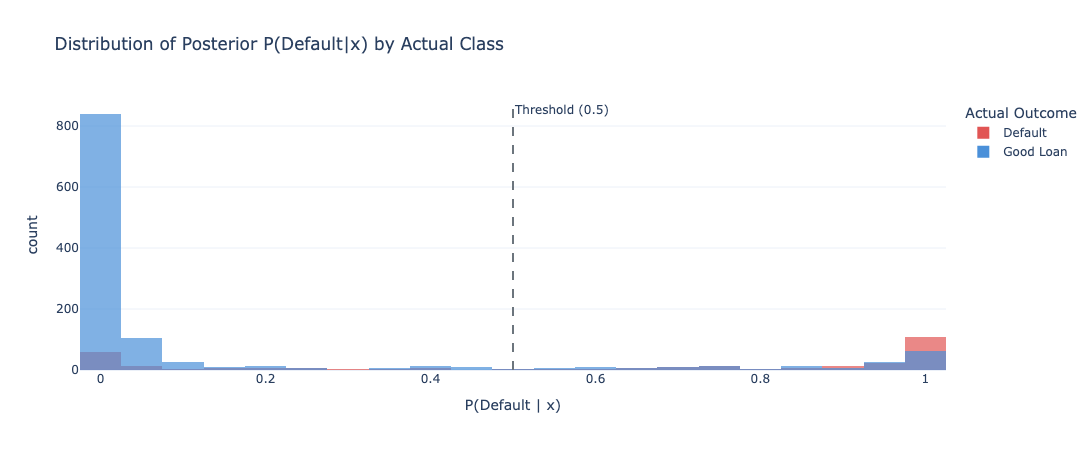

  Saved: outputs/naive_bayes/posterior_distribution.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/naive_bayes/posterior_distribution.html')

In [5]:
prob_df = pd.DataFrame({
    "probability": y_score,
    "actual": y_test.map({0: "Good Loan", 1: "Default"}).values,
})

fig_post = px.histogram(
    prob_df, x="probability", color="actual",
    nbins=50, barmode="overlay", opacity=0.7,
    title="Distribution of Posterior P(Default|x) by Actual Class",
    labels={"probability": "P(Default | x)", "actual": "Actual Outcome"},
    color_discrete_map={"Good Loan": COLORS["accent"], "Default": COLORS["red"]},
    height=450, width=650,
)
fig_post.add_vline(x=0.5, line_dash="dash", line_color=COLORS["gray"],
                   annotation_text="Threshold (0.5)")
fig_post.show()
save_chart(fig_post, MODEL_SLUG, "posterior_distribution")

---
## 7. Var Smoothing Sensitivity

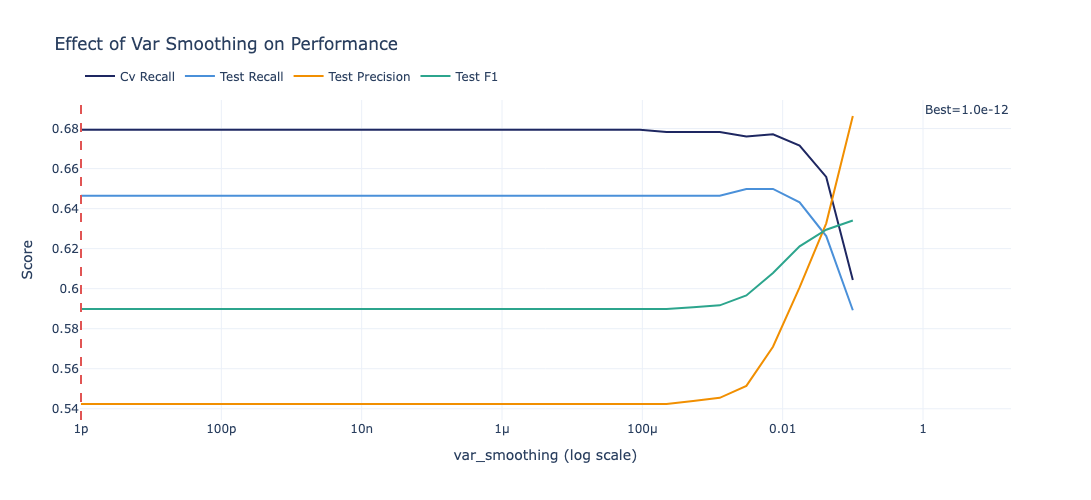

  Saved: outputs/naive_bayes/var_smoothing_sensitivity.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/naive_bayes/var_smoothing_sensitivity.html')

In [6]:
smoothing_values = np.logspace(-12, -1, 30)
smooth_results = []

for vs in smoothing_values:
    nb_temp = Pipeline([
        ("prep", prep_linear),
        ("clf", GaussianNB(var_smoothing=vs)),
    ])
    cv_sc = cross_val_score(nb_temp, X_train, y_train, cv=cv, scoring="recall").mean()
    nb_temp.fit(X_train, y_train)
    y_pred_t = nb_temp.predict(X_test)
    y_prob_t = nb_temp.predict_proba(X_test)[:, 1]

    smooth_results.append({
        "var_smoothing": vs,
        "cv_recall": cv_sc,
        "test_recall": recall_score(y_test, y_pred_t),
        "test_precision": precision_score(y_test, y_pred_t, zero_division=0),
        "test_f1": f1_score(y_test, y_pred_t),
        "test_auc": roc_auc_score(y_test, y_prob_t),
    })

df_smooth = pd.DataFrame(smooth_results)

fig_smooth = go.Figure()
for m, color in [("cv_recall", COLORS["navy"]), ("test_recall", COLORS["accent"]),
                  ("test_precision", COLORS["orange"]), ("test_f1", COLORS["green"])]:
    fig_smooth.add_trace(go.Scatter(
        x=df_smooth["var_smoothing"], y=df_smooth[m],
        name=m.replace("_", " ").title(),
        line=dict(color=color, width=2),
    ))

best_vs = grid.best_params_["clf__var_smoothing"]
fig_smooth.add_vline(x=best_vs, line_dash="dash", line_color=COLORS["red"],
                     annotation_text=f"Best={best_vs:.1e}")

fig_smooth.update_layout(
    title="Effect of Var Smoothing on Performance",
    xaxis_title="var_smoothing (log scale)", xaxis_type="log",
    yaxis_title="Score",
    height=500, width=700,
    legend=dict(orientation="h", y=1.12),
)
fig_smooth.show()
save_chart(fig_smooth, MODEL_SLUG, "var_smoothing_sensitivity")

---
## 8. Decision Boundary (2D PCA Projection)

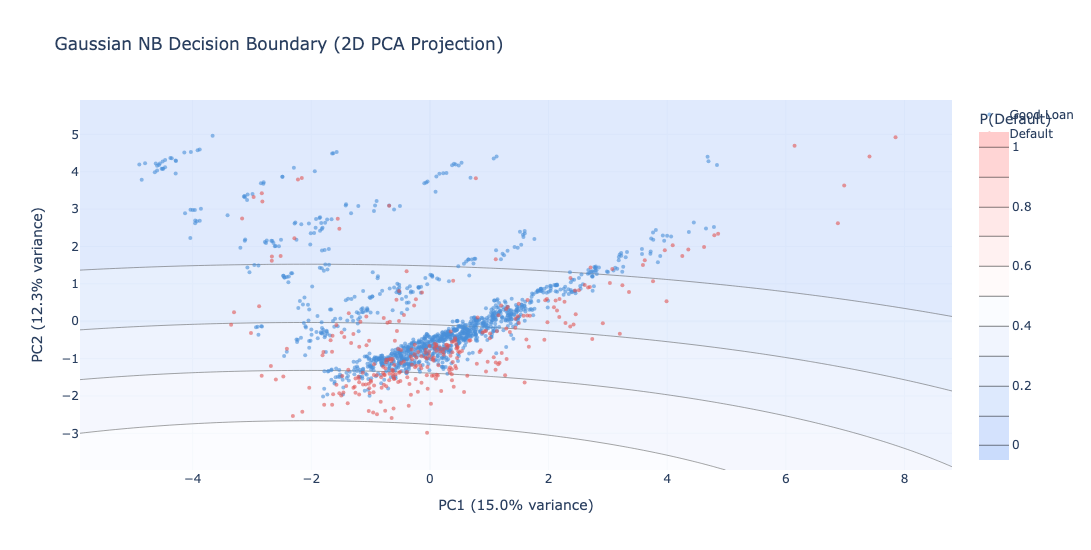

  Saved: outputs/naive_bayes/decision_boundary_2d.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/naive_bayes/decision_boundary_2d.html')

In [7]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_t)
X_test_2d = pca.transform(X_test_t)

nb_2d = GaussianNB()
nb_2d.fit(X_train_2d, y_train)

h = 0.1
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = nb_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

fig_db = go.Figure()
fig_db.add_trace(go.Contour(
    x=np.arange(x_min, x_max, h), y=np.arange(y_min, y_max, h), z=Z,
    colorscale=[[0, COLORS["ice"]], [0.5, COLORS["white"]], [1, "#ffcccc"]],
    contours=dict(start=0, end=1, size=0.1),
    showscale=True, colorbar=dict(title="P(Default)"), opacity=0.7,
))
for label, color, name in [(0, COLORS["accent"], "Good Loan"), (1, COLORS["red"], "Default")]:
    mask = y_test == label
    fig_db.add_trace(go.Scatter(
        x=X_test_2d[mask, 0], y=X_test_2d[mask, 1],
        mode="markers", name=name,
        marker=dict(color=color, size=4, opacity=0.6),
    ))

fig_db.update_layout(
    title="Gaussian NB Decision Boundary (2D PCA Projection)",
    xaxis_title=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
    yaxis_title=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)",
    height=550, width=700,
)
fig_db.show()
save_chart(fig_db, MODEL_SLUG, "decision_boundary_2d")

---
## 9. Diagnostic Charts


Saving universal charts for Gaussian Naive Bayes:
  Saved: outputs/naive_bayes/roc_curve.html
  Saved: outputs/naive_bayes/precision_recall_curve.html
  Saved: outputs/naive_bayes/confusion_matrix.html
  Saved: outputs/naive_bayes/threshold_sweep.html


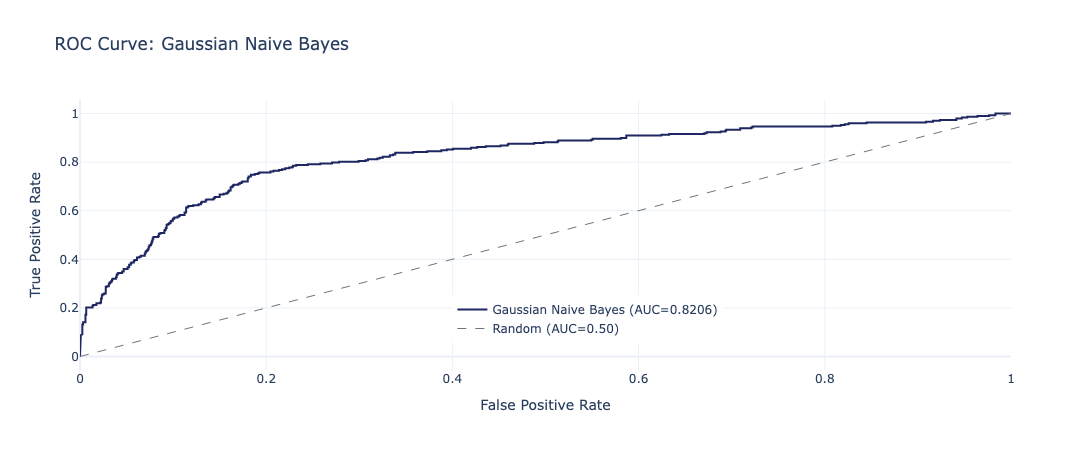

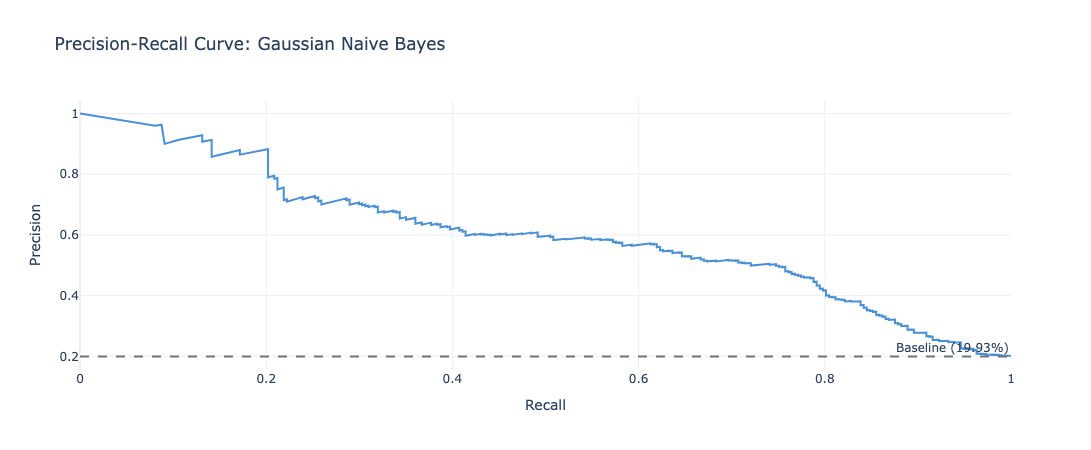

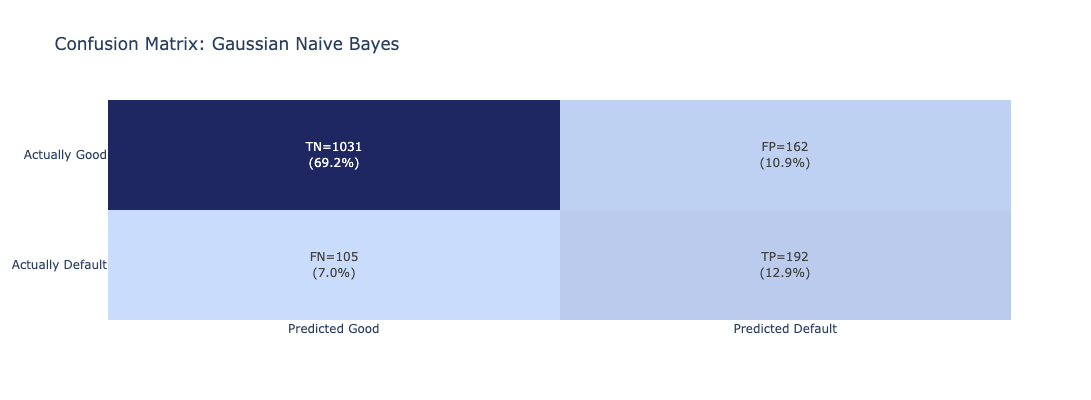

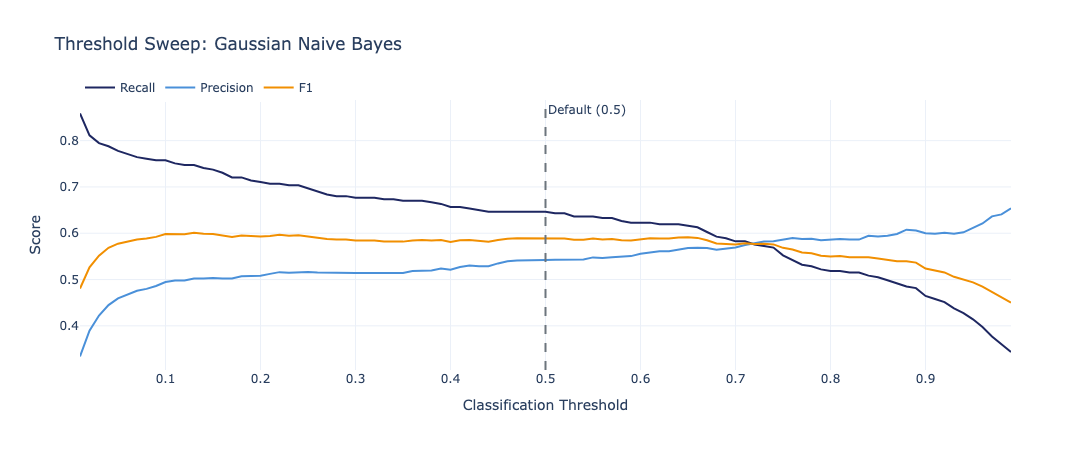

In [8]:
charts = save_all_universal_charts(y_test, y_pred, y_score, MODEL_NAME, MODEL_SLUG)
for name, fig in charts.items():
    fig.show()

---
## 10. Summary

### Where Gaussian Naive Bayes Sits on the Tradeoff Spectrum

Gaussian NB tends toward the **aggressive end** of the spectrum for this problem. The Gaussian assumption on features combined with the class prior means the model readily assigns high default probabilities when feature values deviate from the "good loan" distribution, even if the deviations are small. This results in relatively high recall but lower precision.

### Strengths for This Problem
- Extremely fast to train and predict (just computing means and variances)
- Works well with small training sets (minimal parameters to estimate)
- Naturally handles class imbalance through the prior
- Provides calibrated posterior probabilities (when the Gaussian assumption holds)
- No hyperparameters to tune (var_smoothing has minimal impact)

### Limitations for This Problem
- The naive independence assumption is violated (LOAN and VALUE are correlated)
- The Gaussian assumption may not hold for skewed features (DELINQ, DEROG are zero-inflated)
- Cannot capture feature interactions
- Often outperformed by models that relax these assumptions
- Probabilities can be poorly calibrated when assumptions are violated

### Key Takeaway
Gaussian NB is the **probabilistic baseline**. It provides a principled starting point grounded in Bayesian statistics. If it performs well, the features are informative and roughly independent. If it performs poorly, it indicates either strong feature dependencies or non-Gaussian distributions, pointing toward models that can handle these complexities.

---
*Notebook by Trinidad Cisneros — MIT Applied Data Science Program, April 2026*